✅ Changed working directory to: /home/jovyan/DISSERTATION 
🚀 Starting Debug Plot...
📊 Plotting Task: testC_000


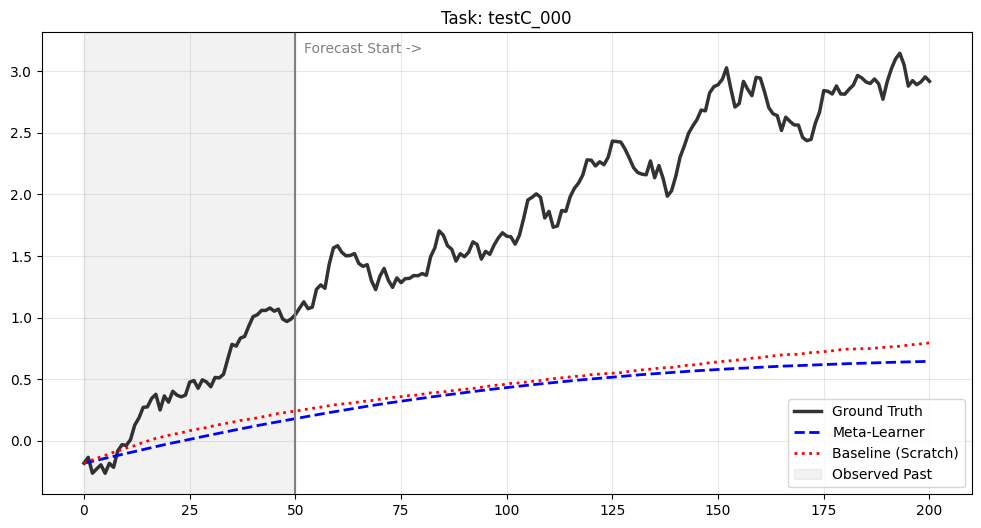

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
import sys
import torch

# --- PATH FIX: Set Working Directory to Project Root ---
# Get the current folder
current_dir = os.getcwd()

# If we are in a subfolder (like 'plots'), find the parent
if "plots" in current_dir or "experiments" in current_dir:
    project_root = os.path.dirname(current_dir)
    os.chdir(project_root) # <--- THIS FIXES THE FILE NOT FOUND ERROR
    print(f"✅ Changed working directory to: {os.getcwd()}")
    
    if project_root not in sys.path:
        sys.path.append(project_root)
else:
    project_root = current_dir
    print(f"✅ Working directory is already root: {os.getcwd()}")
# -------------------------------------------------------

# Now imports and file paths will work correctly
from config.base_config import cfg
from adaptation.few_shot_adapt import get_task_data, infer_z_star, train_from_scratch, simulate_neural_sde_batch
from models.encoder import TrajEncoder
from models.neural_sde import NeuralSDE
from models.head import ForecastHead

def main():
    print("🚀 Starting Debug Plot...")
    device = torch.device(cfg.device)

    # 1. Load Checkpoint
    ckpt_path = "checkpoints/meta_epoch_50.pt"
    if not os.path.exists(ckpt_path):
        print(f"❌ Error: Checkpoint not found at {ckpt_path}")
        return

    ckpt = torch.load(ckpt_path, map_location=device)
    x_dim = cfg.basis.x_dim
    z_dim = cfg.latent.latent_dim
    
    # 2. Rebuild Models
    encoder = TrajEncoder(x_dim, z_dim, cfg.latent.encoder_hidden_dim).to(device)
    sde = NeuralSDE(x_dim, z_dim, cfg.latent.sde_hidden_dim).to(device)
    head = ForecastHead(x_dim, z_dim, cfg.latent.head_hidden_dim).to(device)
    
    encoder.load_state_dict(ckpt['encoder'])
    sde.load_state_dict(ckpt['sde'])
    head.load_state_dict(ckpt['head'])
    
    # 3. Load Data (Test C)
    from dataloaders.trajectory_datasets import TrajectoryDataset
    index_path = os.path.join(cfg.paths.data_root, "index.csv")
    
    try:
        ds = TrajectoryDataset(index_path, "testC", "support")
    except:
        print("⚠️ Falling back to TestA")
        ds = TrajectoryDataset(index_path, "testA", "support")

    theta_id = ds.metadata['theta_id'].unique()[0]
    print(f"📊 Plotting Task: {theta_id}")
    
    # 4. Get Data & Run Models
    full_data = get_task_data(ds, theta_id, device)
    support = full_data[:2]
    query = full_data[2:3]
    
    # Meta-Learner
    z = infer_z_star(encoder, support, 50) 
    gen = torch.Generator(device=device).manual_seed(999)
    x0 = query[:, 0, :]
    z_exp = z.expand(x0.size(0), -1)
    meta_path = simulate_neural_sde_batch(sde, x0, z_exp, cfg.time_grid.T, cfg.time_grid.n_steps, 100.0, gen)
    
    # Baseline
    sde_scr, head_scr, z_scr = train_from_scratch(x_dim, z_dim, support, cfg, gen)
    scr_path = simulate_neural_sde_batch(sde_scr, x0, z_scr.expand(x0.size(0), -1), cfg.time_grid.T, cfg.time_grid.n_steps, 100.0, gen)
    
    # 5. Plot
    path_true = query[0, :, 0].cpu().numpy()
    path_meta = meta_path[0, :, 0].detach().cpu().numpy()
    path_scr = scr_path[0, :, 0].detach().cpu().numpy()
    
    plt.figure(figsize=(12, 6))
    plt.plot(path_true, 'k-', label='Ground Truth', linewidth=2.5, alpha=0.8)
    plt.plot(path_meta, 'b--', label='Meta-Learner', linewidth=2)
    plt.plot(path_scr, 'r:', label='Baseline (Scratch)', linewidth=2)
    
    plt.axvline(x=50, color='gray', linestyle='-')
    plt.text(52, max(path_true), "Forecast Start ->", color='gray')
    plt.axvspan(0, 50, color='gray', alpha=0.1, label='Observed Past')
    
    plt.title(f"Task: {theta_id}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    main()